# 03 - Exploratory Data Analysis (EDA)

## Objective

In this notebook, I explore the Telco churn dataset to understand where churn is concentrated and which customer groups look riskier.

At this stage, I am not trying to prove causality. The goal is to observe patterns, compare customer groups, and collect useful signals for the modeling stage.

The main questions are:

- How balanced is the churn target?
- Which contract types are associated with higher churn?
- Do monthly charges and tenure differ between churned and non-churned customers?
- Which service and payment groups show stronger churn patterns?
- Are there features that look weak or less useful for modeling?

This notebook helps me move from raw data to business understanding before building models.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("../data/raw/telco.csv")
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,City,Zip Code,Latitude,Longitude,Population,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,Los Angeles,90022,34.023810,-118.156582,68701,Q3,No,0,1,NaN,No,0.00,No,Yes,DSL,8,No,No,Yes,No,No,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,Los Angeles,90063,34.044271,-118.185237,55668,Q3,Yes,1,8,Offer E,Yes,48.85,Yes,Yes,Fiber Optic,17,No,Yes,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,80.65,633.30,0.00,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,Los Angeles,90065,34.108833,-118.229715,47534,Q3,No,0,18,Offer D,Yes,11.33,Yes,Yes,Fiber Optic,52,No,No,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,Inglewood,90303,33.936291,-118.332639,27778,Q3,Yes,1,25,Offer C,Yes,19.76,No,Yes,Fiber Optic,12,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,Whittier,90602,33.972119,-118.020188,26265,Q3,Yes,1,37,Offer C,Yes,6.33,Yes,Yes,Fiber Optic,14,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [4]:
eda_df = df.copy()

none_like_cols = ["Offer", "Internet Type", "Churn Category", "Churn Reason"]
for col in none_like_cols:
    if col in eda_df.columns:
        eda_df[col] = eda_df[col].replace("None", pd.NA)

## Churn Label Distribution

In [5]:
eda_df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [6]:
eda_df["Churn Label"].value_counts(normalize=True)

Churn Label
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [7]:
churn_palette = {
    "No": "#4CC4C6",
    "Yes": "#e05e01"
}

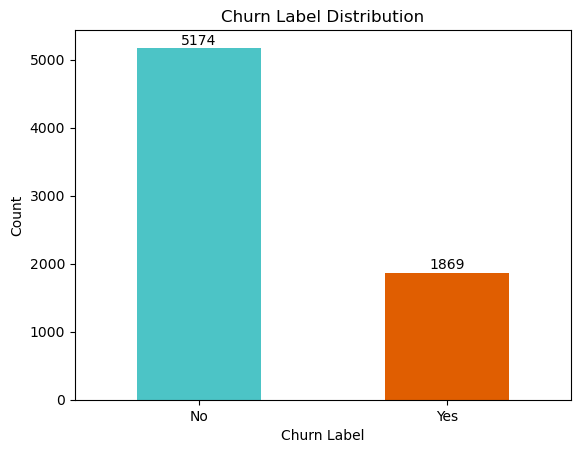

In [8]:
churn_counts = eda_df["Churn Label"].value_counts()

ax = churn_counts.plot(
    kind="bar",
    color=[churn_palette[label] for label in churn_counts.index]
)

plt.title("Churn Label Distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)

for i, value in enumerate(churn_counts.values):
    ax.text(i, value + 50, str(value), ha="center")

plt.show()

### Interpretation

The target variable is not evenly distributed.

Most customers did not churn, while a smaller but still meaningful group did churn.

This means accuracy alone will not be enough during model evaluation. A model could look accurate by predicting the majority class too often.

Because of that, later model evaluation should also include precision, recall, F1-score, and ROC-AUC.

## Contract Type vs Churn

In [9]:
contract_churn = pd.crosstab(eda_df["Contract"], eda_df["Churn Label"], normalize="index")
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-Month,0.541551,0.458449
One Year,0.892903,0.107097
Two Year,0.974509,0.025491


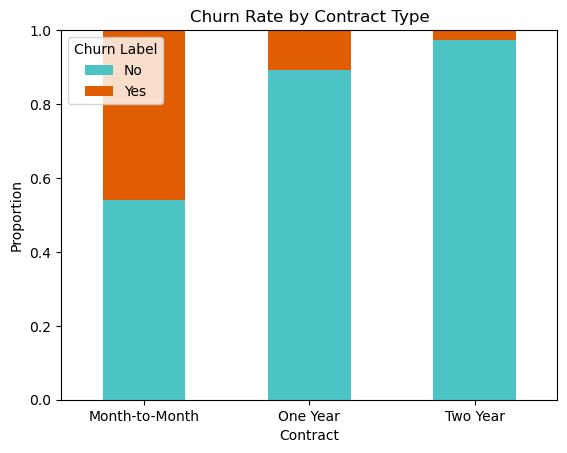

In [10]:
ax = contract_churn.plot(
    kind="bar",
    stacked=True,
    color=[churn_palette[col] for col in contract_churn.columns]
)


plt.title("Churn Rate by Contract Type")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(title="Churn Label")
plt.ylim(0, 1)
plt.show()

### Interpretation

Churn differs clearly by contract type.

Customers with month-to-month contracts have the highest churn share. Customers with one-year and especially two-year contracts have much lower churn.

This makes business sense because customers with short-term contracts can leave more easily.

For the modeling stage, `Contract` is likely to be one of the most important categorical features.

### Monthly Charges vs. Churn

C:\Users\mirza\AppData\Local\Temp\ipykernel_18892\1877277203.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


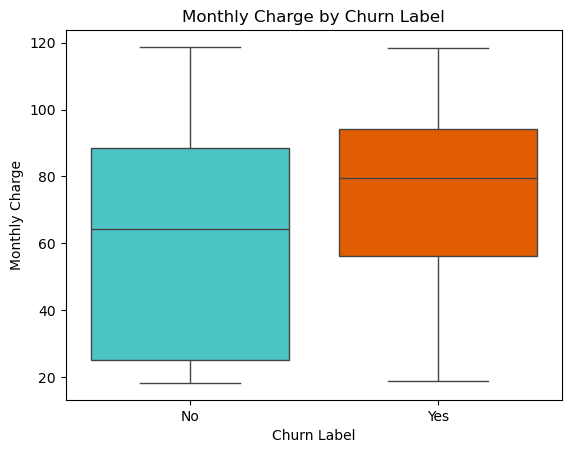

In [11]:
sns.boxplot(
    x="Churn Label",
    y="Monthly Charge",
    data=eda_df,
    order=["No", "Yes"],
    palette=churn_palette,
    saturation=1
)

plt.title("Monthly Charge by Churn Label")
plt.xlabel("Churn Label")
plt.ylabel("Monthly Charge")
plt.show()

This boxplot compares the distribution of monthly charges for churned and non-churned customers.

Key Observations:
- **Higher Median Cost:** Customers who churn (Yes) have a noticeably higher median monthly charge compared to those who stay (No).
- **Price Sensitivity:** The concentration of churned customers in the higher price range suggests that high costs may be a significant driver of customer loss.
- **Retention in Lower Brackets:** Non-churned customers show a wider distribution with a lower median, indicating that lower-priced plans might contribute to better retention.

This insight suggests that pricing strategies or high-value plan satisfaction should be further investigated.


## Tenure in Months vs Churn

C:\Users\mirza\AppData\Local\Temp\ipykernel_18892\213969297.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


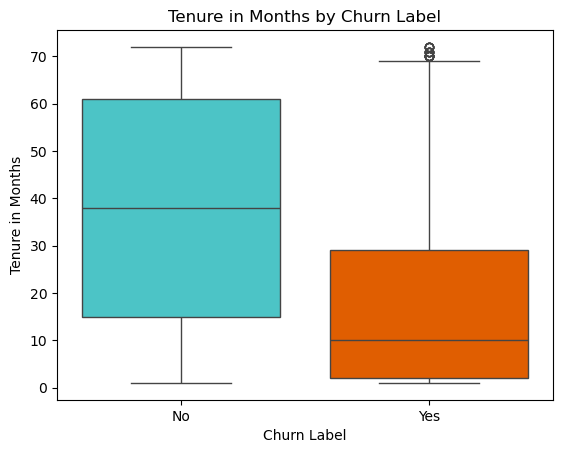

In [12]:
sns.boxplot(
    x="Churn Label",
    y="Tenure in Months",
    data=eda_df,
    order=["No", "Yes"],
    palette=churn_palette,
    saturation=1
)

plt.title("Tenure in Months by Churn Label")
plt.xlabel("Churn Label")
plt.ylabel("Tenure in Months")
plt.show()

### Detailed Interpretation:
1. **The Loyalty Gap:** The median tenure for churned customers is significantly lower (~10-15 months) compared to non-churned customers (~38 months). This indicates a high early churn rate, suggesting that the first year is the most critical period for customer retention.
2. **Predictive Power:** Since the distributions of the two classes are visually distinct, `Tenure in Months` will likely be one of the top features for our machine learning model.
3. **Strategic Recommendation:** Marketing efforts should focus on the "Early Tenure" segment (0-12 months) with engagement programs to decrease churn probability before they reach the 2-year mark.

## Total Charges vs Churn

C:\Users\mirza\AppData\Local\Temp\ipykernel_18892\3824985300.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


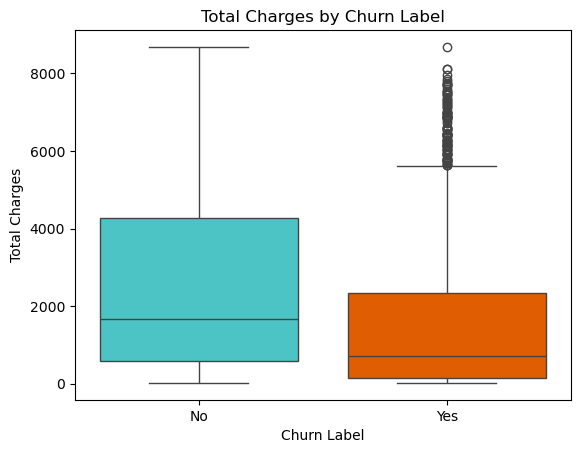

In [13]:
sns.boxplot(
    x="Churn Label",
    y="Total Charges",
    data=eda_df,
    order=["No", "Yes"],
    palette=churn_palette,
    saturation=1
)

plt.title("Total Charges by Churn Label")
plt.xlabel("Churn Label")
plt.ylabel("Total Charges")
plt.show()

### Interpretation

Customers who churned tend to have lower total charges.

At first, this may look like lower total spending is related to churn. But it should be interpreted together with tenure.

Customers with shorter tenure naturally have less time to accumulate total charges. Because of this, `Total Charges` may overlap strongly with `Tenure in Months` and `Monthly Charge`.

This is an important point to remember later when deciding which features are safe and useful for the final model.

## Monthly Charge vs Tenure by Churn Label

A raw scatterplot of `Monthly Charge` versus `Tenure in Months` produced substantial overlap between churn classes and was difficult to interpret clearly.

To make the pattern more readable, tenure was grouped into broader ranges and churn behavior was examined at the group level instead.

In [14]:
eda_df["Tenure Group"] = pd.cut(
    eda_df["Tenure in Months"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"],
    include_lowest=True
)

In [15]:
tenure_group_churn = pd.crosstab(
    eda_df["Tenure Group"],
    eda_df["Churn Label"],
    normalize="index"
)

tenure_group_churn

Churn Label,No,Yes
Tenure Group,,
0-12,0.525618,0.474382
13-24,0.712891,0.287109
25-48,0.796110,0.203890
49-72,0.904868,0.095132


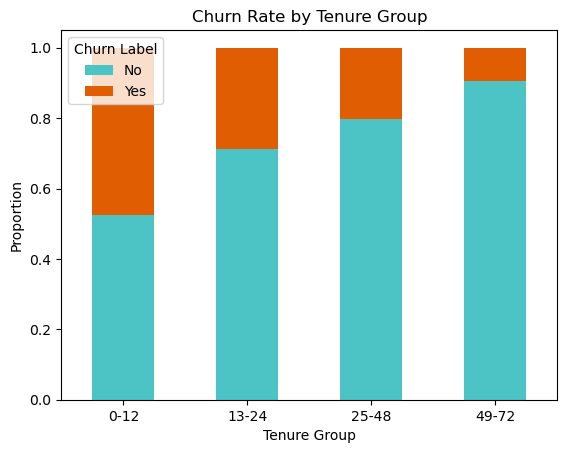

In [16]:
tenure_group_churn.plot(
    kind="bar",
    stacked=True,
    color=[churn_palette[col] for col in tenure_group_churn.columns]
)

plt.title("Churn Rate by Tenure Group")
plt.ylabel("Proportion")
plt.xlabel("Tenure Group")
plt.xticks(rotation=0)
plt.legend(title="Churn Label")
plt.show()

### Interpretation

Grouping tenure into broader ranges makes the churn pattern easier to read than a raw scatterplot.

The distribution suggests that shorter-tenure customers are more likely to churn, while longer-tenure customers are more likely to remain.

In [17]:
eda_df.groupby(["Tenure Group", "Churn Label"])["Monthly Charge"].median().unstack()

C:\Users\mirza\AppData\Local\Temp\ipykernel_18892\2240341911.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eda_df.groupby(["Tenure Group", "Churn Label"])["Monthly Charge"].median().unstack()


Churn Label,No,Yes
Tenure Group,,
0-12,45.400,73.850
13-24,55.325,84.525
25-48,64.200,89.100
49-72,80.325,99.900


C:\Users\mirza\AppData\Local\Temp\ipykernel_18892\4105234654.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_by_tenure = eda_df.groupby(["Tenure Group", "Churn Label"])["Monthly Charge"].median().unstack()


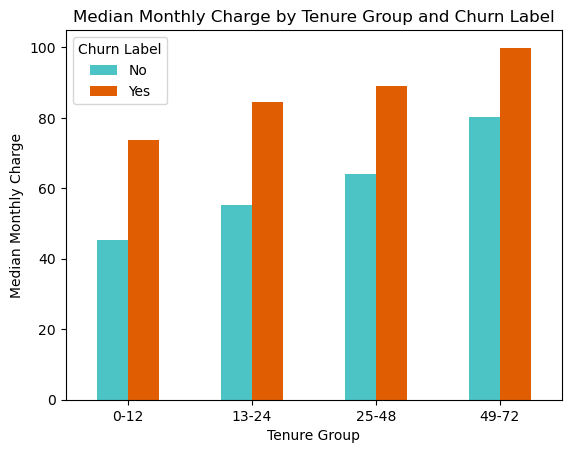

In [18]:
monthly_by_tenure = eda_df.groupby(["Tenure Group", "Churn Label"])["Monthly Charge"].median().unstack()

monthly_by_tenure.plot(
    kind="bar",
    color=[churn_palette[col] for col in monthly_by_tenure.columns]
)

plt.title("Median Monthly Charge by Tenure Group and Churn Label")
plt.ylabel("Median Monthly Charge")
plt.xlabel("Tenure Group")
plt.xticks(rotation=0)
plt.legend(title="Churn Label")
plt.show()

### Interpretation

This grouped view shows that churn is especially concentrated among customers in the first 12 months.

Within this shorter-tenure group, monthly charges also appear relatively high, which may indicate that price sensitivity is more pronounced early in the customer lifecycle.

At this stage, this is treated as an observed pattern rather than a causal conclusion.

## Interim EDA Summary

The first part of the EDA shows that churn is not evenly distributed across the customer base.

The clearest early patterns are:

- churn is higher among month-to-month customers
- churned customers tend to have higher monthly charges
- churned customers tend to have shorter tenure
- lower total charges among churned customers are likely related to shorter tenure

At this point, I am treating these as observed patterns, not causal explanations.

The next step is to check whether categorical service and payment features show similar churn differences.

## Internet Type vs Churn

In [19]:
internet_churn = pd.crosstab(
    eda_df["Internet Type"],
    eda_df["Churn Label"],
    normalize="index"
)

internet_churn

Churn Label,No,Yes
Internet Type,,
Cable,0.743373,0.256627
DSL,0.814165,0.185835
Fiber Optic,0.592751,0.407249


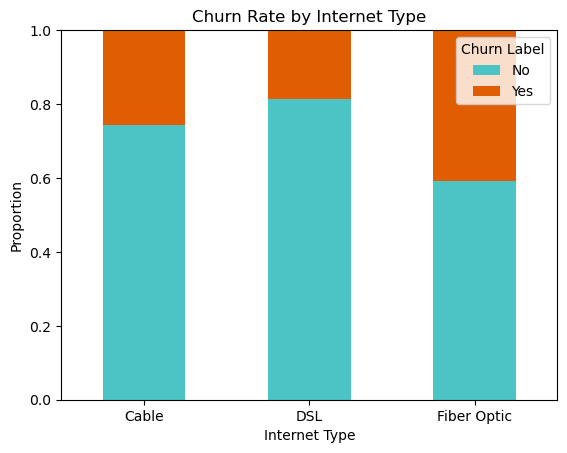

In [20]:
internet_churn.plot(
    kind="bar",
    stacked=True,
    color=[churn_palette[col] for col in internet_churn.columns]
)

plt.title("Churn Rate by Internet Type")
plt.ylabel("Proportion")
plt.xlabel("Internet Type")
plt.xticks(rotation=0)
plt.legend(title="Churn Label")
plt.ylim(0, 1)
plt.show()

### Interpretation

Churn rates differ meaningfully by internet type.

Fiber Optic customers show a higher churn share compared with other internet types.

This is an important business pattern, but I do not interpret it as “Fiber Optic causes churn.” It may be connected with price, service expectations, competition, customer segment, or other related factors.

For modeling, `Internet Type` still looks like a useful feature because it separates customer groups with different churn behavior.

## Payment Method vs Churn

In [21]:
payment_churn = pd.crosstab(
    eda_df["Payment Method"],
    eda_df["Churn Label"],
    normalize="index"
)

payment_churn

Churn Label,No,Yes
Payment Method,,
Bank Withdrawal,0.660015,0.339985
Credit Card,0.855220,0.144780
Mailed Check,0.631169,0.368831


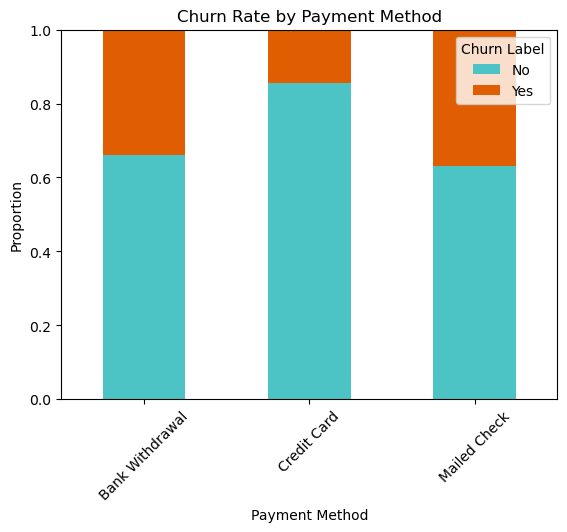

In [22]:
payment_churn.plot(
    kind="bar",
    stacked=True,
    color=[churn_palette[col] for col in payment_churn.columns]
)

plt.title("Churn Rate by Payment Method")
plt.ylabel("Proportion")
plt.xlabel("Payment Method")
plt.xticks(rotation=45)
plt.legend(title="Churn Label")
plt.ylim(0, 1)
plt.show()

### Interpretation

**Payment Method Influence**: Churn rates vary significantly depending on how customers pay.

**Highest Risk**: Customers using Bank Withdrawal and Mailed Check exhibit the highest churn rates (approx. 34% and 37% respectively).

**Lowest Risk**: Customers paying via Credit Card are the most loyal, with a significantly lower churn rate of only 14.5%.

**Strategic Insight**: The high churn in "Mailed Check" and "Bank Withdrawal" might be due to transaction failures or a lack of automatic renewal convenience compared to Credit Cards.

## Gender vs Churn

In [23]:
gender_churn = pd.crosstab(
    eda_df["Gender"],
    eda_df["Churn Label"],
    normalize="index"
)

gender_churn

Churn Label,No,Yes
Gender,,
Female,0.730791,0.269209
Male,0.738397,0.261603


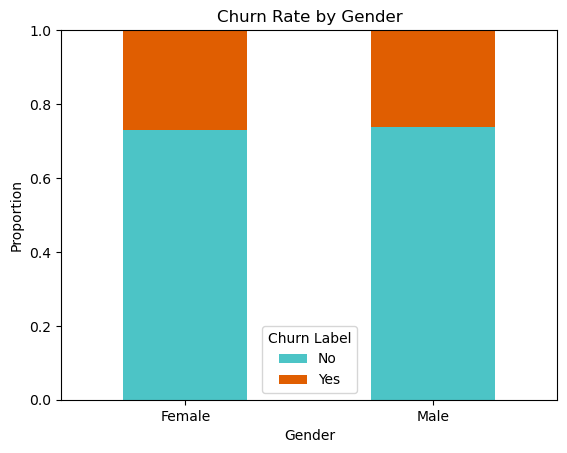

In [24]:
gender_churn.plot(
    kind="bar",
    stacked=True,
    color=[churn_palette[col] for col in gender_churn.columns]
)

plt.title("Churn Rate by Gender")
plt.ylabel("Proportion")
plt.xlabel("Gender")
plt.xticks(rotation=0)
plt.legend(title="Churn Label")
plt.ylim(0, 1)
plt.show()

### Interpretation

Churn rates are very similar across gender groups.

This suggests that `Gender` is not a strong churn signal in this dataset.

I will still let the modeling pipeline handle it as a categorical feature, but based on EDA, I do not expect it to be one of the most important predictors.

## Categorical EDA Summary

The categorical analysis shows that some categorical variables carry much stronger churn signal than others.

The clearest patterns are:

- `Internet Type` shows meaningful churn differences.
- `Payment Method` shows meaningful churn differences.
- `Contract` remains one of the strongest churn-related categorical features.
- `Gender` does not show a meaningful churn difference.

This helps separate features that may be useful for modeling from features that are less informative.

## Advanced EDA / Deeper Pattern Exploration

## Correlation Analysis

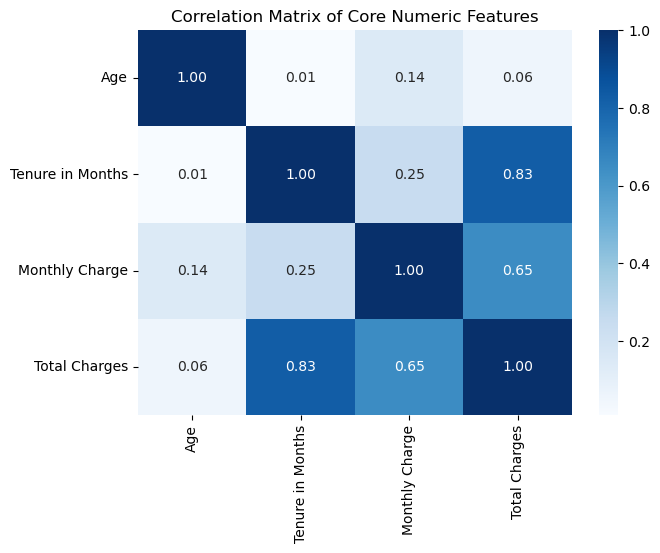

In [25]:
corr_cols = ["Age", "Tenure in Months", "Monthly Charge", "Total Charges"]
corr_matrix = eda_df[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Matrix of Core Numeric Features")
plt.show()

### Interpretation

The strongest correlation appears between `Tenure in Months` and `Total Charges`.

This is expected because customers with longer tenure naturally accumulate more total charges.

`Monthly Charge` also has a moderate relationship with `Total Charges`.

This is important for the final Logistic Regression model because correlated numerical features can make coefficient interpretation harder.

At this stage, I am not removing any feature yet, but this result is a useful warning for the final feature decision.

## Monthly Charge Groups vs Churn

In [26]:
eda_df["Monthly Charge Group"] = pd.cut(
    eda_df["Monthly Charge"],
    bins=[0, 30, 70, 120],
    labels=["0-30", "31-70", "71+"],
    include_lowest=True
)

charge_group_churn = pd.crosstab(
    eda_df["Monthly Charge Group"],
    eda_df["Churn Label"],
    normalize="index"
)

charge_group_churn

Churn Label,No,Yes
Monthly Charge Group,,
0-30,0.901996,0.098004
31-70,0.756502,0.243498
71+,0.646386,0.353614


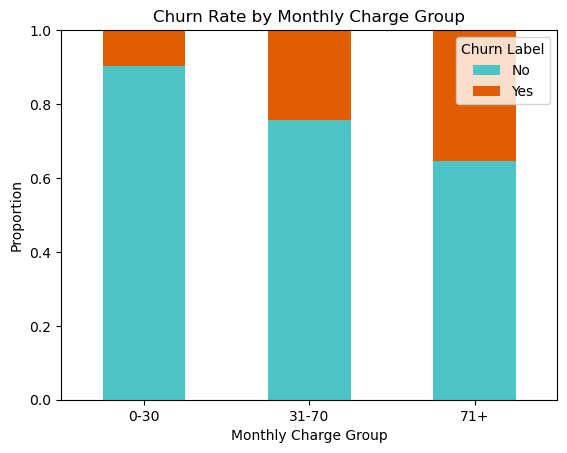

In [27]:
charge_group_churn.plot(
    kind="bar",
    stacked=True,
    color=[churn_palette[col] for col in charge_group_churn.columns]
)

plt.title("Churn Rate by Monthly Charge Group")
plt.ylabel("Proportion")
plt.xlabel("Monthly Charge Group")
plt.xticks(rotation=0)
plt.legend(title="Churn Label")
plt.ylim(0, 1)
plt.show()

### Interpretation

Grouping monthly charges makes the pricing pattern easier to read.

Churn share increases as monthly charge group increases. Customers in higher monthly charge groups show higher churn share than customers in lower charge groups.

Again, this does not prove that price alone causes churn. But it suggests that monthly charge is an important business feature to keep in the modeling pipeline.

## Total Services vs Churn

In [28]:
service_cols = [
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection Plan",
    "Premium Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Streaming Music",
    "Unlimited Data"
]

eda_df["Total Services"] = (eda_df[service_cols] == "Yes").sum(axis=1)

service_churn = pd.crosstab(
    eda_df["Total Services"],
    eda_df["Churn Label"],
    normalize="index"
)

service_churn

Churn Label,No,Yes
Total Services,,
1,0.911839,0.088161
2,0.846154,0.153846
3,0.531008,0.468992
4,0.575198,0.424802
5,0.640152,0.359848
6,0.652500,0.347500
7,0.696286,0.303714
8,0.760431,0.239569
9,0.780952,0.219048


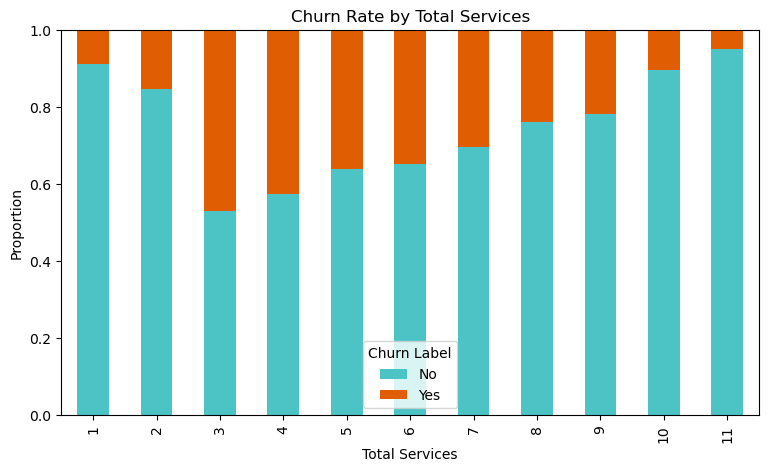

In [29]:
service_churn.plot(
    kind="bar",
    stacked=True,
    color=[churn_palette[col] for col in service_churn.columns],
    figsize=(9, 5)
)

plt.title("Churn Rate by Total Services")
plt.ylabel("Proportion")
plt.xlabel("Total Services")
plt.legend(title="Churn Label")
plt.ylim(0, 1)
plt.show()

### Interpretation

**Service Stickiness**: This analysis examines the relationship between the number of subscribed services and churn. While the pattern is not purely linear, it confirms that service adoption is a key behavioral indicator.

**The Mid-Range Risk**: Churn is highest among customers with a mid-range number of services. This might represent "vulnerable" customers who use the core service but haven't fully integrated into the ecosystem.

**The Loyalty Threshold**: Customers with very high service counts (6+) appear significantly less likely to churn. This suggests a "lock-in" effect where the complexity of switching all services to a competitor acts as a natural barrier to leaving.

**Beyond Simplicity**: The relationship is more complex than a simple “more services means lower churn” rule, indicating that the type or combination of services may matter as much as the quantity.

## Churn by Internet Type and Contract

In [30]:
combo_churn = pd.crosstab(
    [eda_df["Internet Type"], eda_df["Contract"]],
    eda_df["Churn Label"],
    normalize="index"
)

combo_churn

Churn Label                         No       Yes
Internet Type Contract                          
Cable         Month-to-Month  0.557920  0.442080
              One Year        0.879581  0.120419
              Two Year        0.986111  0.013889
DSL           Month-to-Month  0.667090  0.332910
              One Year        0.911330  0.088670
              Two Year        0.980392  0.019608
Fiber Optic   Month-to-Month  0.411796  0.588204
              One Year        0.833049  0.166951
              Two Year        0.945230  0.054770

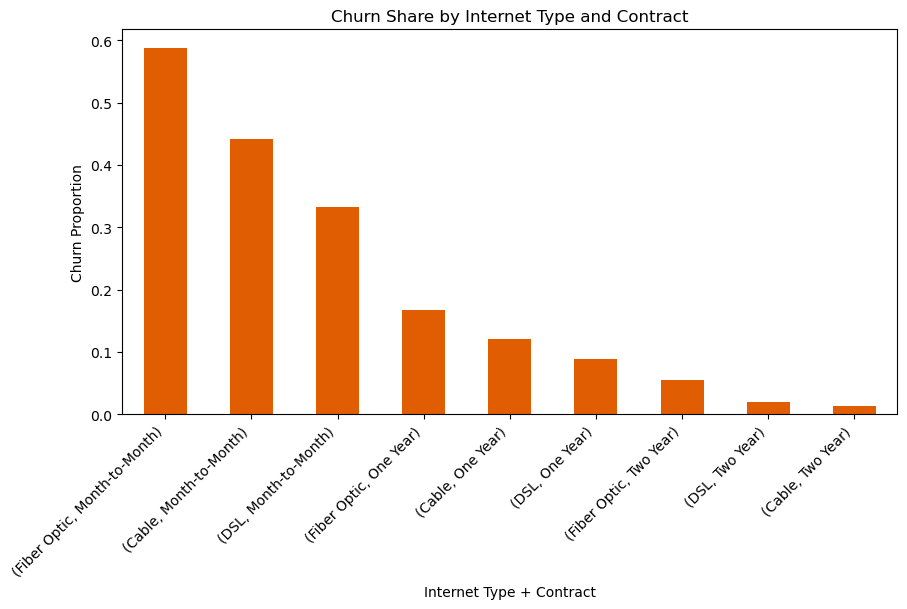

In [31]:
combo_churn["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    color=churn_palette["Yes"],
    figsize=(10, 5)
)

plt.title("Churn Share by Internet Type and Contract")
plt.ylabel("Churn Proportion")
plt.xlabel("Internet Type + Contract")
plt.xticks(rotation=45, ha="right")
plt.show()

### Interpretation

**Risk Concentration**: Churn is not evenly distributed; it is highly concentrated within specific combinations of service and commitment.

**The "Perfect Storm" for Churn**: The segment of Fiber Optic customers on Month-to-Month contracts represents the highest risk in the entire dataset. This suggests that high-speed service users who lack a long-term commitment are the most likely to switch providers.

**The Stability Factor**: Regardless of the internet technology used, Two Year contracts effectively neutralize churn risk, bringing it near zero. This highlights that the contract structure is a more powerful loyalty driver than the technology itself.

**Feature Engineering Insight**: These findings suggest that the interaction between Internet Type and Contract should be a priority feature in our predictive modeling to capture these non-linear risks.

## Senior Citizen, Payment Method and Churn

In [38]:
senior_payment = pd.crosstab(
    eda_df["Senior Citizen"],
    eda_df["Payment Method"],
    normalize="index"   
)

senior_payment

Payment Method,Bank Withdrawal,Credit Card,Mailed Check
Senior Citizen,,,
No,0.522284,0.418065,0.059651
Yes,0.724168,0.246935,0.028897


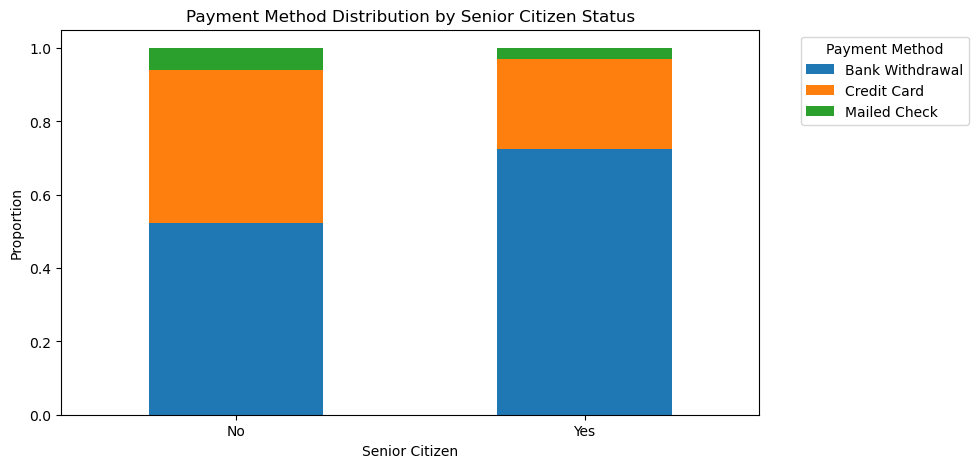

In [39]:
senior_payment.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Payment Method Distribution by Senior Citizen Status")
plt.ylabel("Proportion")
plt.xlabel("Senior Citizen")
plt.xticks(rotation=0)
plt.legend(title="Payment Method", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

### Interpretation

This analysis checks whether payment method preferences differ between senior and non-senior customers.

Senior citizens use Bank Withdrawal more often than non-senior customers, while non-senior customers use Credit Card more often.

This does not explain churn by itself, but it helps understand customer behavior before looking at churn by combined segments.

In [40]:
senior_payment_churn = pd.crosstab(
    [eda_df["Senior Citizen"], eda_df["Payment Method"]],
    eda_df["Churn Label"],
    normalize="index"
)

senior_payment_churn

Churn Label                           No       Yes
Senior Citizen Payment Method                     
No             Bank Withdrawal  0.688838  0.311162
               Credit Card      0.876368  0.123632
               Mailed Check     0.633523  0.366477
Yes            Bank Withdrawal  0.552600  0.447400
               Credit Card      0.670213  0.329787
               Mailed Check     0.606061  0.393939

### Interpretation

This cross-tab shows churn proportions for each combination of senior status and payment method.

The results suggest that churn is not evenly distributed across these combinations.

This means payment method may be more informative when it is interpreted together with customer age group.

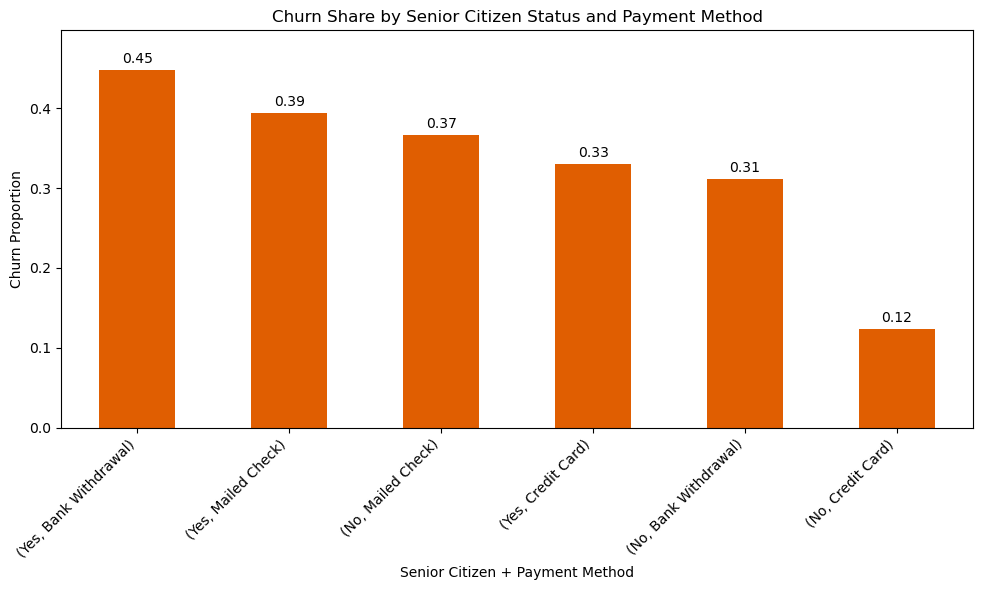

In [44]:
ax = senior_payment_churn["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    color=churn_palette["Yes"],
    figsize=(10, 6)
)

ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)

plt.title("Churn Share by Senior Citizen Status and Payment Method")
plt.ylabel("Churn Proportion")
plt.xlabel("Senior Citizen + Payment Method")
plt.xticks(rotation=45, ha="right")


plt.ylim(0, max(senior_payment_churn["Yes"]) + 0.05) 

plt.tight_layout()
plt.show()

### Interpretation

This chart highlights the highest-risk combinations more clearly.

The highest churn share appears in the Senior Citizen + Bank Withdrawal segment.

The lowest churn share appears in the Non-Senior + Credit Card segment.

This kind of segment-level view is useful because business actions are usually taken for customer groups, not only for individual features.

## Statistical Check: Gender and Churn

In [42]:
from scipy.stats import chi2_contingency

gender_churn_table = pd.crosstab(
    eda_df["Gender"],
    eda_df["Churn Label"]
)

gender_churn_table

Churn Label,No,Yes
Gender,,
Female,2549,939
Male,2625,930


In [47]:
chi2, p_value, dof, expected = chi2_contingency(gender_churn_table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 0.4840828822091383
p-value: 0.48657873605618596
Degrees of freedom: 1


### Interpretation

I used a chi-square test to check whether the relationship between `Gender` and `Churn Label` is statistically significant.

The p-value is **0.4866**, which is higher than the common 0.05 threshold.

This means the test does not provide strong evidence that gender and churn are meaningfully associated in this dataset.

This result also supports the visual EDA result, where churn rates for male and female customers looked almost the same.

## Final EDA Summary

The EDA shows that churn is not randomly distributed across customers.

The strongest patterns I observed are:

- Month-to-Month customers have much higher churn.
- Fiber Optic customers appear as an important churn-related segment.
- Shorter-tenure customers are more likely to churn.
- Higher monthly charge groups show higher churn share.
- Credit Card customers show lower churn share than other payment methods.
- Fiber Optic + Month-to-Month is one of the clearest high-risk segments.
- Senior Citizen + Bank Withdrawal is another important high-risk segment.
- Gender does not show a meaningful relationship with churn.

The main takeaway from this notebook is that churn is strongly connected with customer contract, service, payment, tenure, and monthly charge patterns.

These findings will guide the preprocessing and modeling stages, but I will avoid treating EDA patterns as direct causal claims.